# Conditional Treatment Effect of low impact activities
Activities `c310, c320, c340, c370, c410, c430, c440, c510` are expected to have less of an impact on flood losses, based on theoretical considerations. In this notebook, we will test this theoretical intuitions

In [1]:
import os
import numpy as np 
from astropy.table import Table as aT

In [2]:
from noah2 import data as D
from noah2 import util as U

In [3]:
from causalflow import causalflow
from causalflow import support as Support

In [4]:
import torch

In [5]:
import corner as DFM
# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [6]:
cuda = torch.cuda.is_available()
device = ("cuda:0" if cuda else "cpu")

# read data
read full data set

In [10]:
# read CRS participant data
DNoah = D.Noah2()
fema = DNoah._read_data_full()

columns = DNoah._columns()[:8]
column_labels = np.array(DNoah._column_labels()[:8])

# binary activity codes
binary_activities = ['c360', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

binary_data = np.array([np.array(fema[col]) for col in binary_activities]).T
binary_data = (binary_data > 0).astype(int)

binary_act_codes = np.zeros(len(fema)).astype(int)
for i in range(binary_data.shape[1]):
    binary_act_codes += 2**i * binary_data[:,i]

# compile training data
_data = np.array([np.array(fema[col]) for col in columns]).T
# reduce dynamical range
_data[:,0] = np.log10(_data[:,0])
_data[:,3] = np.log10(_data[:,3])
_data[:,4] = np.log10(_data[:,4])

In [11]:
activities = [] 
for col in fema.colnames: 
    if 's_c' in col and '_avg' not in col:
        activities.append(col[2:])

In [12]:
highimpact_activities = ['c350', 'c360', 'c420', 'c450', 'c520', 'c530', 'c540', 'c610', 'c620', 'c630']

i_highimpact, i_lowimpact = [], []
for i in range(len(activities)): 
    if activities[i] not in highimpact_activities: 
        i_lowimpact.append(i)
    else: 
        i_highimpact.append(i)
i_highimpact = np.array(i_highimpact)
i_lowimpact = np.array(i_lowimpact)

## identify communities that only perform low-impact activities

In [13]:
# codify the activities
scores = np.zeros((len(fema), len(activities)))

for i in range(len(activities)): 
    scores[:,i] = fema[activities[i]]
    
act_codes = np.zeros(len(fema))
for i in range(len(activities)): 
    act_codes += 2**i * (scores[:,i] > 0).astype(int)
    
def uncode(num): 
    act = np.zeros(len(activities)).astype(int)
    while num > 0: 
        ind = int(np.floor(np.log(num)/np.log(2)))
        num = num - 2**ind
        act[ind] = 1
    return act    

In [14]:
only_lowimpact = np.ones(scores.shape[0]).astype(bool)
for i in i_highimpact: 
    only_lowimpact &= (scores[:,i] == 0)
    
only_lowimpact &= ~(np.all(scores == 0, axis=1))
print('%i communities only participate in low-impact activities' % np.sum(only_lowimpact))
print('%i unique zipcodes only participate in low-impact activities' % len(np.unique(fema['zipcode'][only_lowimpact])))

492 communities only participate in low-impact activities
35 unique zipcodes only participate in low-impact activities


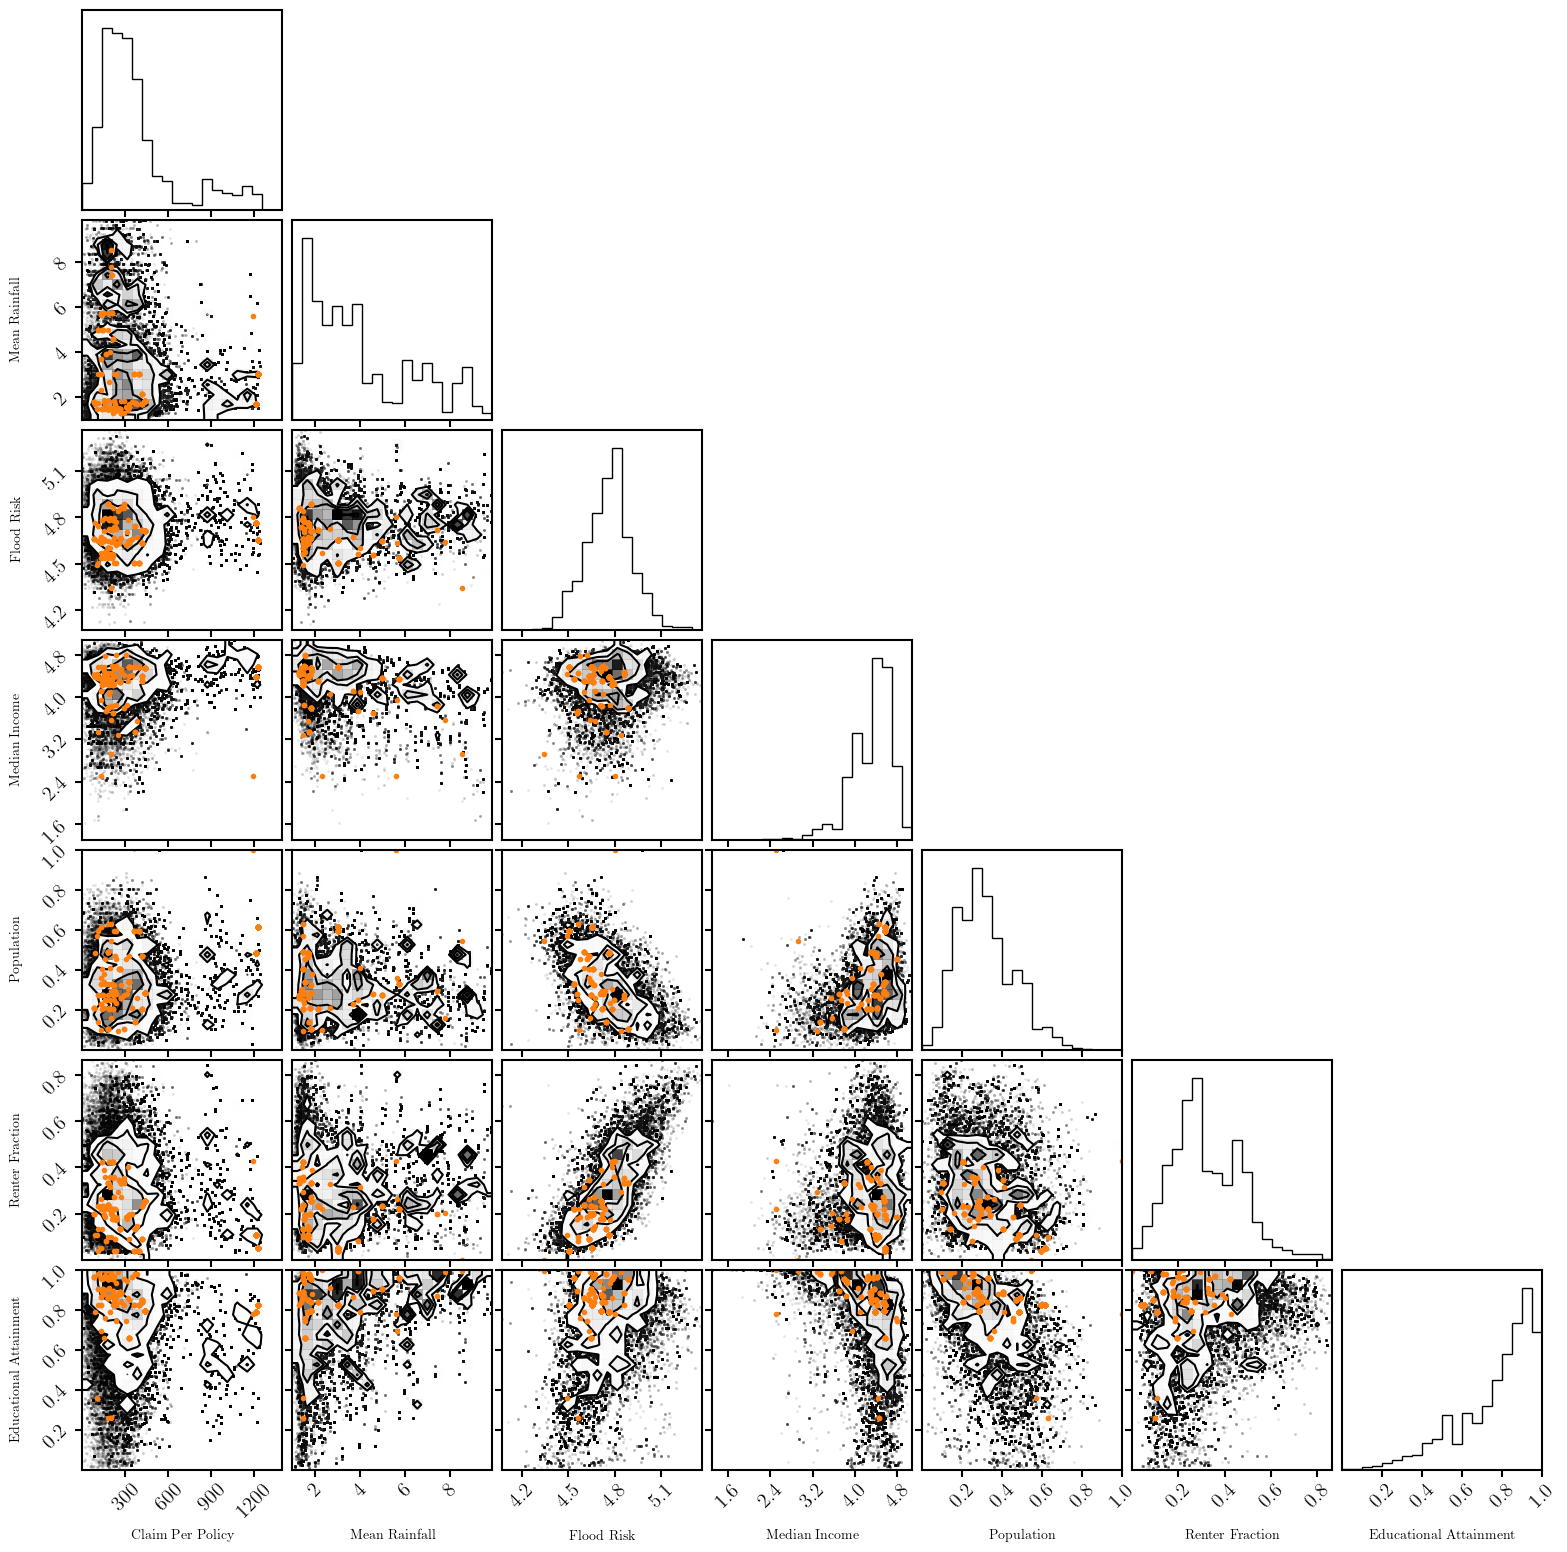

In [15]:
fig = DFM.corner(_data[:,1:], labels=DNoah._column_labels()[:8])
DFM.overplot_points(fig, _data[:,1:][only_lowimpact], color='C1')

these communities perform some combination of low-impact CRS activities

In [17]:
for code in np.unique(act_codes[only_lowimpact]): 
    print('%i communities participate in ' % np.sum(act_codes == code), np.array(activities)[uncode(code).astype(bool)])

375 communities participate in  ['c310']
23 communities participate in  ['c310' 'c410' 'c440']
11 communities participate in  ['c310' 'c330' 'c430' 'c440']
9 communities participate in  ['c310' 'c320' 'c330' 'c430' 'c440']
3 communities participate in  ['c310' 'c340' 'c430' 'c440']
25 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c430' 'c440']
8 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c410' 'c430' 'c440']
8 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c440' 'c510']
23 communities participate in  ['c310' 'c330' 'c430' 'c440' 'c510']
7 communities participate in  ['c310' 'c320' 'c330' 'c430' 'c440' 'c510']


# calculate CTE

In [18]:
# load non-participant support flow
Supp = Support.Support()
Supp.load_optuna('supp.nonpart', '/tigress/chhahn/_scratch/noah/noah2/qphi/', verbose=True)

select best flow out of 73 flows


In [19]:
Cflow = causalflow.CausalFlowB('control') # non-participant is the base distribution
# load support
Cflow.load_support(Supp)

# load flow
Cflow.load_flows_optuna('flow.nonpart', '/tigress/chhahn/_scratch/noah/noah2/qphi/', verbose=True)

select 5 out of 18 flows


calculate CTE for each set of low impact only communities

In [20]:
ctes_all, zipcodes_all, in_support_all = [], [], []
for code in np.unique(act_codes[only_lowimpact]): 
    print('%i communities participate in ' % np.sum(act_codes == code), np.array(activities)[uncode(code).astype(bool)])
    treated = _data[(act_codes == code)]
    
    Y_treated = treated[:,0][:,None]
    X_treated = treated[:,1:]

    # zipcode of treated communities for jackknife error
    z_treated = fema['zipcode'][act_codes == code]
    zipcodes_all.append(z_treated)
    
    # check support
    in_support = Cflow.support_base.check_support(X_treated, Nsample=10000, threshold=0.95)
    in_support_all.append(in_support)

    # calculate Conditional Treatment Effect
    ctes = []
    for _X, _Y in zip(X_treated, Y_treated): 
        cte = Cflow.CTE(_X, _Y, Nsample=10000, Nsupport=10000, 
                       support_threshold=0.95, transf=lambda x: 10**x)
        ctes.append(cte)  
    ctes = np.array(ctes)
    ctes_all.append(ctes)

    # get jackknife uncertainties
    njack = 5
    cte_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((z_treated % njack) == i) & in_support 
        if np.sum(in_jack) == 0: continue

        cte_jack.append(np.mean(ctes[~in_jack]))
        n_jack += 1

    sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((cte_jack - np.mean(ctes[in_support]))**2))

    print('avg %.2f +/- %.2f' % (np.mean(ctes[in_support]), sig_jack))

    # get jackknife uncertainties
    njack = 5
    cte_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((z_treated % njack) == i) & in_support 
        if np.sum(in_jack) == 0: continue

        cte_jack.append(np.median(ctes[~in_jack]))
        n_jack += 1

    sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((cte_jack - np.median(ctes[in_support]))**2))

    print('med %.2f +/- %.2f' % (np.median(ctes[in_support]), sig_jack))
    print('nzip = %i, njack = %i' % (len(np.unique(z_treated)), njack))
    print()

375 communities participate in  ['c310']


/home/chhahn/projects/CausalFlow/src/causalflow/causalflow.py:522: UserWarning: covariate is out of the base sample support!
  warnings.warn("covariate is out of the base sample support!")


avg -2854.52 +/- 15397.56
med -19243.02 +/- 16276.30
nzip = 5, njack = 5

23 communities participate in  ['c310' 'c410' 'c440']
avg 904.18 +/- 4165.20
med -3777.97 +/- 6706.83
nzip = 4, njack = 5

11 communities participate in  ['c310' 'c330' 'c430' 'c440']
avg 7487.81 +/- 1727.06
med 9391.97 +/- 2994.52
nzip = 4, njack = 5

9 communities participate in  ['c310' 'c320' 'c330' 'c430' 'c440']


/home/chhahn/.conda/envs/sbi/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/chhahn/.conda/envs/sbi/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


avg -5692.14 +/- nan
med -23450.06 +/- nan
nzip = 1, njack = 5

3 communities participate in  ['c310' 'c340' 'c430' 'c440']
avg -6905.93 +/- nan
med -5148.06 +/- nan
nzip = 1, njack = 5

25 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c430' 'c440']
avg -13059.09 +/- 1118.47
med -12926.36 +/- 6948.45
nzip = 7, njack = 5

8 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c410' 'c430' 'c440']
avg 8577.23 +/- nan
med 2085.31 +/- nan
nzip = 1, njack = 5

8 communities participate in  ['c310' 'c320' 'c330' 'c340' 'c440' 'c510']
avg -10104.30 +/- nan
med -7744.53 +/- nan
nzip = 1, njack = 5

23 communities participate in  ['c310' 'c330' 'c430' 'c440' 'c510']
avg -6053.30 +/- 6104.91
med -7221.76 +/- 6164.74
nzip = 11, njack = 5

7 communities participate in  ['c310' 'c320' 'c330' 'c430' 'c440' 'c510']
avg -7712.36 +/- 5770.52
med -10035.31 +/- 6107.87
nzip = 2, njack = 5



In [21]:
def jackknife_uncertainty(ctes, zips, in_supp, func=np.mean, njack=5): 
    # get jackknife uncertainties
    cte_jack, n_jack = [], 0
    for i in range(njack): 
        in_jack = ((zips % njack) == i) & in_supp
        if np.sum(in_jack) == 0: continue

        cte_jack.append(func(ctes[~in_jack]))
        n_jack += 1

    mu_all = func(ctes[in_supp])
    if len(np.unique(zips)) < 3: 
        sig_jack = np.NaN
    else: 
        sig_jack = np.sqrt((n_jack - 1)/n_jack * np.sum((cte_jack - mu_all)**2))
    return mu_all, sig_jack

In [22]:
mu_all, sig_jack = jackknife_uncertainty(np.concatenate(ctes_all), np.concatenate(zipcodes_all), 
                                         np.concatenate(in_support_all), func=np.mean, njack=10)
print('avg %.2f +/- %.2f' % (mu_all, sig_jack))
print('nzip = %i, njack = %i' % (len(np.unique(np.concatenate(zipcodes_all))), njack))
print()


# mu_all, sig_jack = jackknife_uncertainty(np.concatenate(ctes_all), np.concatenate(zipcodes_all), 
#                                          np.concatenate(in_support_all), func=np.median, njack=10)
# print('med %.2f +/- %.2f' % (mu_all, sig_jack))
# print('nzip = %i, njack = %i' % (len(np.unique(np.concatenate(zipcodes_all))), njack))
# print()

avg -3762.93 +/- 24740.65
nzip = 35, njack = 5



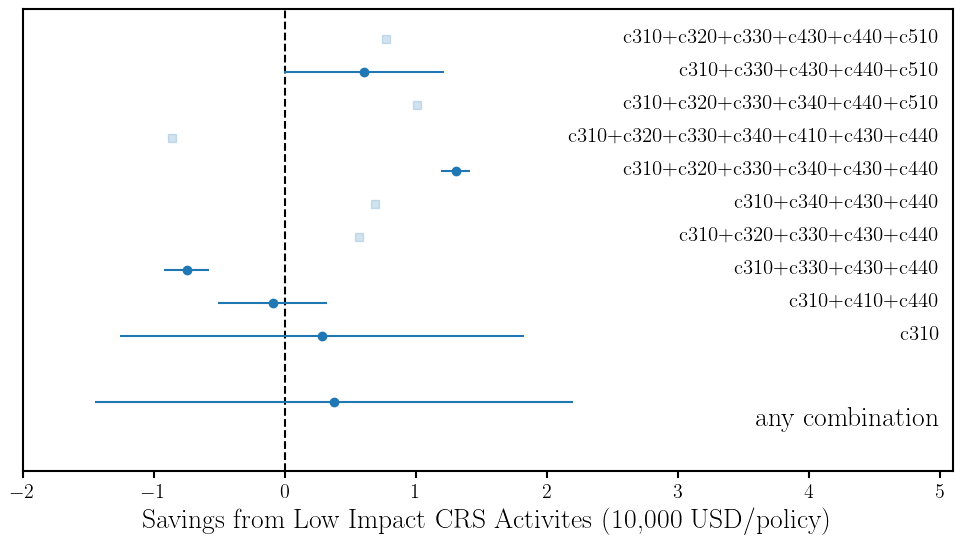

In [24]:
fig = plt.figure(figsize=(12,6))
sub = fig.add_subplot(111)

sub.plot([0., 0.], [-1., 10], c='k', linestyle='--')

# all combinations
#mu_all, sig_jk = jackknife_uncertainty(np.concatenate(ctes_all), np.concatenate(zipcodes_all), 
#                                         np.concatenate(in_support_all), func=np.median, njack=10)

#sub.errorbar([-mu_all/1e4], [-0.05], xerr=[[sig_jk/1e4], [sig_jk/1e4]], fmt='.C2')
#sub.scatter([-mu_all/1e4], [-0.05], c='C2')

mu_all, sig_jk = jackknife_uncertainty(np.concatenate(ctes_all), np.concatenate(zipcodes_all), 
                                         np.concatenate(in_support_all), func=np.mean, njack=5)

sub.errorbar([-mu_all/1e4], [0.05], xerr=[[sig_jk/1e4], [sig_jk/1e4]], fmt='.C0')
sub.scatter([-mu_all/1e4], [0.05], c='C0')

sub.text(5, -0.2, 'any combination', ha='right', va='center', fontsize=20)

for i, code in enumerate(np.unique(act_codes[only_lowimpact])): 
    #mu, sig_jk = jackknife_uncertainty(ctes_all[i], zipcodes_all[i], in_support_all[i], func=np.median, njack=5)
    #if np.isfinite(sig_jk):
    #    sub.errorbar([-mu/1e4], [1+0.5*i-0.05], xerr=[[sig_jk/1e4], [sig_jk/1e4]], fmt='.C2')
    #    sub.scatter([-mu/1e4], [1+0.5*i-0.05], c='C2', alpha=1)
    #else: 
    #    sub.scatter([-mu/1e4], [1+0.5*i-0.05], c='C2', alpha=0.2, marker='s')
        
    mu, sig_jk = jackknife_uncertainty(ctes_all[i], zipcodes_all[i], in_support_all[i], func=np.mean, njack=5)
    if np.isfinite(sig_jk):
        sub.errorbar([-mu/1e4], [1+0.5*i+0.05], xerr=[[sig_jk/1e4], [sig_jk/1e4]], fmt='.C0')
        sub.scatter([-mu/1e4], [1+0.5*i+0.05], c='C0', alpha=1)
    else: 
        sub.scatter([-mu/1e4], [1+0.5*i+0.05], c='C0', alpha=0.2, marker='s')        
        
    sub.text(5, 1+0.5*i, '+'.join(list(np.array(activities)[uncode(code).astype(bool)])), 
             ha='right', va='baseline', fontsize=15)

sub.set_xlabel('Savings from Low Impact CRS Activites (10,000 USD/policy)', fontsize=20)
sub.set_ylim(-1, 6)
sub.set_yticks([])
sub.set_xlim(-2, 5.1)
fig.savefig('cte_lowimpact.pdf', bbox_inches='tight')